### Reading Resutls

In [49]:
import os
import glob
import pandas as pd
from IPython.display import display

# 1. Define your two new folder paths

folder_equal = "../results/equal_M=5000"
folder_unequal = "../results/unequal_M=5000"

cols_to_keep = ["Method", "N", "n", "Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
all_dfs = []

def load_data(folder_path, prob_label):
    if not os.path.exists(folder_path):
        print(f"Warning: Could not find folder '{folder_path}'")
        return

    file_paths = glob.glob(os.path.join(folder_path, "summary_*.csv"))
    for file in file_paths:
        df = pd.read_csv(file)
        available_cols = [c for c in cols_to_keep if c in df.columns]
        df = df[available_cols].copy()

        pop_name = os.path.basename(file).split('_')[1]
        df.insert(0, 'Population', pop_name)
        df.insert(1, 'Probability', prob_label)

        # Rule: In Equal probability, rename standard sampling to Maxe
        # if prob_label == 'Equal':
        #     df['Method'] = df['Method'].replace(['Rand', 'srs', 'SRS', 'Srs'], 'Maxe')

        # (We removed the line that deletes the other methods here!)
        all_dfs.append(df)

load_data(folder_unequal, 'Unequal')
load_data(folder_equal, 'Equal')

master_summary = pd.concat(all_dfs, ignore_index=True)

# Safely average out any duplicate files
numeric_cols = ["Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
master_summary = master_summary.groupby(["Population", "Probability", "Method", "n", "N"])[numeric_cols].mean().reset_index()

if 'Lm' in master_summary.columns:
    master_summary['Lm'] = master_summary['Lm'].clip(lower=-1.5, upper=1.5)

print(f"Success! Loaded methods: {master_summary['Method'].unique()}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(master_summary)

# Keep everything EXCEPT where Probability is 'Equal' AND Method is 'Maxe'
master_summary = master_summary[~((master_summary['Probability'] == 'Equal') & (master_summary['Method'] == 'Maxe'))]
master_summary = master_summary[~((master_summary['Probability'] == 'Unequal') & (master_summary['Method'] == 'Rand'))]

master_summary['Method'] = master_summary['Method'].replace('Rand', 'Maxe')

master_summary['Method'] = master_summary['Method'].replace('Maxe', 'MAX')
master_summary['Method'] = master_summary['Method'].replace('Scps', 'SCP')
master_summary['Method'] = master_summary['Method'].replace('Lopi', 'LPV')
master_summary['Method'] = master_summary['Method'].replace('Wave', 'WAV')

master_summary['Population'] = master_summary['Population'].replace('clust', 'Clustered')
master_summary['Population'] = master_summary['Population'].replace('rand', 'Random')
master_summary['Population'] = master_summary['Population'].replace('grid', 'Gridded')
master_summary['Ls'] = master_summary['Ls'].clip(-1.5, 1.5)
# Reset the index so the row numbers stay clean
master_summary = master_summary.reset_index(drop=True)
#display(master_summary)
print(f"Success! Loaded methods: {master_summary['Method'].unique()}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


Success! Loaded methods: ['Lopi' 'Maxe' 'Rand' 'Scps' 'Wave' 'GRZ' 'NMS']


,Population,Probability,Method,n,N,Dm,Ds,Vm,Vs,Mm,Ms,Lm,Ls
0,clust,Equal,Lopi,4.0,144.0,-0.009391,0.286982,0.153205,0.089442,-0.244573,0.129479,0.398958,0.090220
1,clust,Equal,Lopi,8.0,144.0,-0.006147,0.155625,0.141389,0.072423,-0.279418,0.088735,0.223512,0.061206
2,clust,Equal,Lopi,16.0,144.0,-0.011151,0.098023,0.184224,0.060531,-0.312942,0.077067,0.190123,0.034676
3,clust,Equal,Lopi,32.0,144.0,-0.008697,0.057604,0.165909,0.042519,-0.412183,0.073641,0.128982,0.018501
4,clust,Equal,Maxe,4.0,144.0,-0.241394,0.349677,0.299156,0.203990,-0.081968,0.123875,0.533801,0.151186
5,clust,Equal,Maxe,8.0,144.0,-0.184539,0.314408,0.434059,0.283214,-0.046954,0.110633,0.395805,0.112407
6,clust,Equal,Maxe,16.0,144.0,-0.088660,0.235903,0.453953,0.227041,-0.030705,0.106563,0.290500,0.061071
7,clust,Equal,Maxe,32.0,144.0,-0.047101,0.163351,0.417020,0.147739,-0.015652,0.110008,0.199498,0.037542
8,clust,Equal,Rand,4.0,144.0,-0.245435,0.342724,0.301235,0.211779,-0.081180,0.121258,0.532737,0.153286
9,clust,Equal,Rand,8.0,144.0,-0.173571,0.315450,0.427871,0.274516,-0.049325,0.110435,0.393527,0.110135


Success! Loaded methods: ['LPV' 'MAX' 'SCP' 'WAV' 'GRZ' 'NMS']


In [50]:
import os
print(os.getcwd())


/home/bardia/graphical-sampling/simulations/jupyters


✅ Saved PDF: /home/bardia/graphical-sampling/simulations/plot/plot_synthetic_populations_comparison.pdf
✅ Saved PNG: /home/bardia/graphical-sampling/simulations/plot/plot_synthetic_populations_comparison.png


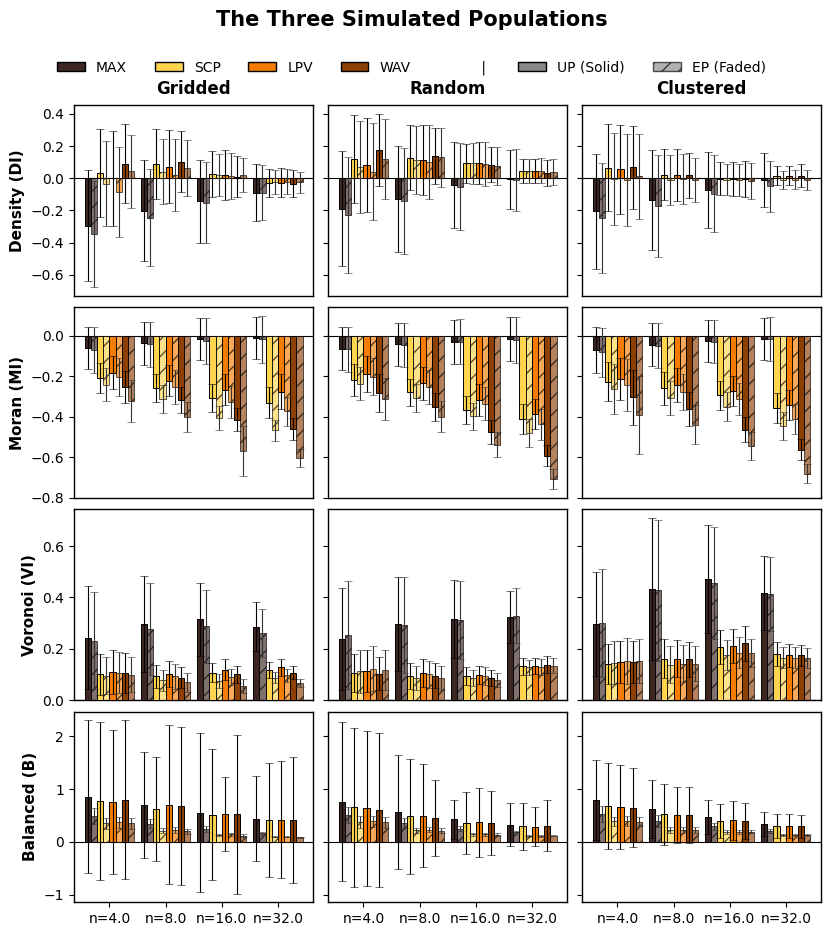

In [51]:
import os
SAVE_DIR = "/home/bardia/graphical-sampling/simulations/plot"

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (DI)'),
    ('Mm', 'Ms', 'Moran (MI)'),
    ('Vm', 'Vs', 'Voronoi (VI)'),
    ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['Gridded', 'Random', 'Clustered' ]

all_methods = ['MAX', 'SCP', 'LPV', 'WAV']


#4A235A
#3E2723
#1A237E
color_dict = {
    'MAX': '#3E2723',  # Rich Ocean Teal (Vibrant but professional)
    'SCP': '#FFD54F',  # Bright Sun Yellow
    'LPV': '#F57C00',  # Vibrant Orange-Gold
    'WAV': '#8D4004',  # Deep Amber / Bronze
}

# --- FIXED: Pushed to maximum safe article width (8.5 inches) ---
fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(target_populations),
                         figsize=(8.5, 9.5), sharey='row')

fig.suptitle("The Three Simulated Populations",
             fontsize=15, fontweight='bold', y=0.98)

# --- FIXED: Thicker bars to use the newly added width ---
num_methods = len(all_methods)
total_cluster_width = 0.88  # Use 88% of the available space per 'n' group
method_width = total_cluster_width / num_methods
bar_width = method_width * 0.5  # Equal/Unequal pairs touch perfectly

# --- FIXED: Thinner outlines so the colors are visible ---
line_width = 0.7

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):
        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]

        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))

        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]

            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)

            offset = (i - num_methods/2 + 0.5) * method_width

            # 1. Unequal (Plain Bar)
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width,
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=line_width,
                   capsize=3,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.4, 'ecolor': 'black'},
                   zorder=3)

            # 2. Equal (Hatched Bar)
            # Reduced hatch density to '//' and increased alpha to 0.65 for better visibility
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width,
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=line_width, hatch='//',
                   alpha=0.65,
                   capsize=3,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.4, 'ecolor': '#333333'},
                   zorder=3)

        # --- Formatting ---
        if row_idx == 0: ax.set_title(pop.capitalize(), fontsize=12, fontweight='bold', pad=8)
        if col_idx == 0: ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')

        ax.set_xticks(x_pos)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=10)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Build a smart custom legend
legend_elements = [mpatches.Patch(facecolor=color_dict[m], edgecolor='black', label=m) for m in all_methods]
legend_elements.append(mpatches.Patch(facecolor='white', edgecolor='white', label=' | '))
legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', label='UP (Solid)'))
legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', hatch='//', alpha=0.65, label='EP (Faded)'))

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=len(legend_elements), fontsize=10, frameon=False)

plt.tight_layout()

# Pulled the frames tightly together
plt.subplots_adjust(top=0.88, wspace=0.06, hspace=0.06)

# --- FIXED: Save as both Vector (PDF) and Raster (PNG) ---
# --- Ensure save directory exists ---
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Save as both Vector (PDF) and Raster (PNG) ---
pdf_save_path = os.path.join(
    SAVE_DIR, "plot_synthetic_populations_comparison.pdf"
)
png_save_path = os.path.join(
    SAVE_DIR, "plot_synthetic_populations_comparison.png"
)

plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(png_save_path, format='png', dpi=300, bbox_inches='tight')

print(f"✅ Saved PDF: {pdf_save_path}")
print(f"✅ Saved PNG: {png_save_path}")

plt.show()

✅ Saved PDF: /home/bardia/graphical-sampling/simulations/plot/plot_meuse.pdf
✅ Saved PNG: /home/bardia/graphical-sampling/simulations/plot/plot_meuse.png


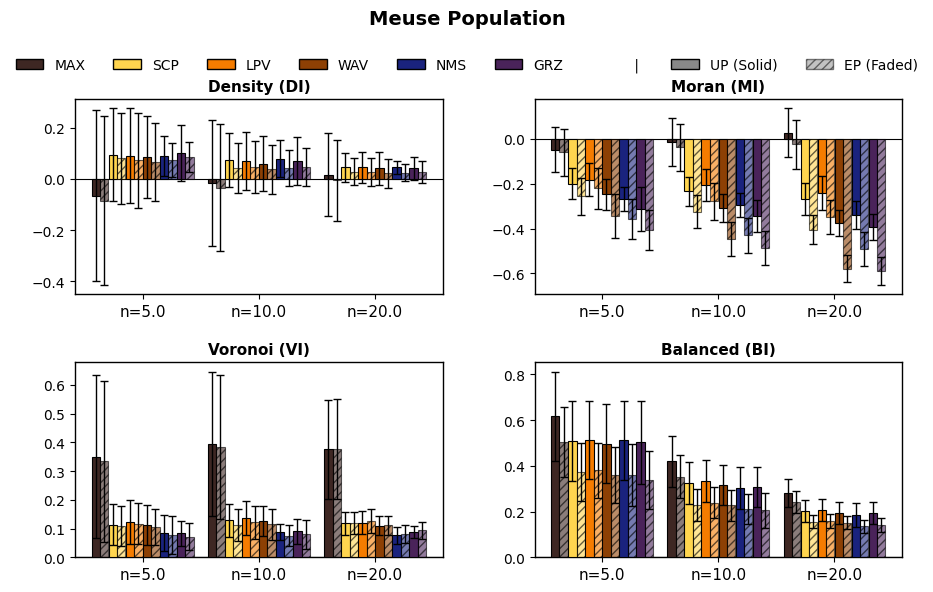

✅ Saved PDF: /home/bardia/graphical-sampling/simulations/plot/plot_swiss.pdf
✅ Saved PNG: /home/bardia/graphical-sampling/simulations/plot/plot_swiss.png


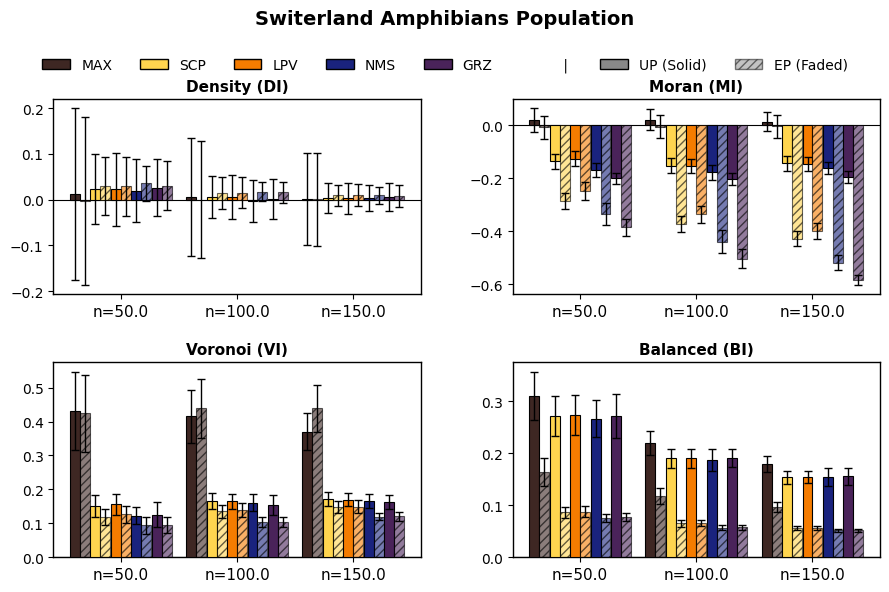

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
target_metrics = [
    ('Dm', 'Ds', 'Density (DI)'),
    ('Mm', 'Ms', 'Moran (MI)'),
    ('Vm', 'Vs', 'Voronoi (VI)'),
    ('Lm', 'Ls', 'Balanced (BI)')
]
all_methods = ['MAX', 'SCP', 'LPV', 'WAV', 'NMS', 'GRZ']


#4A235A
#3E2723
#1A237E
color_dict = {
    'MAX': '#3E2723',  # Rich Ocean Teal (Vibrant but professional)
    'SCP': '#FFD54F',  # Bright Sun Yellow
    'LPV': '#F57C00',  # Vibrant Orange-Gold
    'WAV': '#8D4004',  # Deep Amber / Bronze
    'NMS': '#1A237E',
    'GRZ': '#4A235A'
}
def plot_real_dataset_all_methods(dataset_name, save_plot=False):
    # --- FIXED: Slightly wider figure (9, 6) for better bar spacing ---
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 6))
    if dataset_name == 'meuse':
        fig.suptitle(f"{dataset_name.capitalize()} Population",
                    fontsize=14, fontweight='bold', y=0.98)
    else:
        fig.suptitle(f"Switerland Amphibians Population",
                    fontsize=14, fontweight='bold', y=0.98)
    axes = axes.flatten()
    pop_data = master_summary[master_summary['Population'] == dataset_name]

    if pop_data.empty:
        print(f"Warning: No data found for '{dataset_name}' population.")
        return

    active_methods = [m for m in all_methods if m in pop_data['Method'].unique()]

    n_vals = sorted(pop_data['n'].unique())
    x_pos = np.arange(len(n_vals))

    # --- FIXED: Adjusted Bar Widths ---
    # Increased total width used per 'n' group from 0.8 to 0.88
    total_group_width = 0.88
    method_width = total_group_width / len(active_methods)

    # Increased bar_width from 45% to 48.5% of the method_width.
    # This makes the bars thicker and reduces the empty gap between them.
    bar_width = method_width * 0.485

    for idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
        ax = axes[idx]

        for i, method in enumerate(active_methods):
            m_data = pop_data[pop_data['Method'] == method]
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)

            offset = (i - len(active_methods)/2 + 0.5) * method_width

            # 1. Unequal
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width,
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=0.8,
                   capsize=3,
                   error_kw={'elinewidth': 1.0, 'capthick': 1.0, 'ecolor': 'black'}, zorder=3)

            # 2. Equal
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width,
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=0.8, hatch='////',
                   alpha=0.6, # Slightly increased alpha to make the faded bars pop more
                   capsize=3,
                   error_kw={'elinewidth': 1.0, 'capthick': 1.0, 'ecolor': 'black'}, zorder=3)

        # Formatting
        ax.set_title(metric_name, fontsize=11, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11, zorder=2)
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)

        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

    local_legend_elements = [mpatches.Patch(facecolor=color_dict[m], edgecolor='black', label=m) for m in active_methods]
    local_legend_elements.append(mpatches.Patch(facecolor='white', edgecolor='white', label=' | '))
    local_legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', label='UP (Solid)'))
    local_legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', hatch='////', alpha=0.5, label='EP (Faded)'))

    fig.legend(handles=local_legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92),
               ncol=len(local_legend_elements), fontsize=10, frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(top=0.83, wspace=0.25, hspace=0.35)

    if save_plot:
        os.makedirs(SAVE_DIR, exist_ok=True)  # make the folder if it doesn’t exist yet

        pdf_filename = os.path.join(SAVE_DIR, f"plot_{dataset_name}.pdf")
        png_filename = os.path.join(SAVE_DIR, f"plot_{dataset_name}.png")

        plt.savefig(pdf_filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"✅ Saved PDF: {pdf_filename}")

        plt.savefig(png_filename, format='png', dpi=300, bbox_inches='tight')
        print(f"✅ Saved PNG: {png_filename}")

    plt.show()

# Run it!
plot_real_dataset_all_methods('meuse', save_plot=True)
plot_real_dataset_all_methods('swiss', save_plot=True)

✅ Saved: /home/bardia/graphical-sampling/simulations/plot/moran_meuse_swiss.pdf
✅ Saved: /home/bardia/graphical-sampling/simulations/plot/moran_meuse_swiss.png


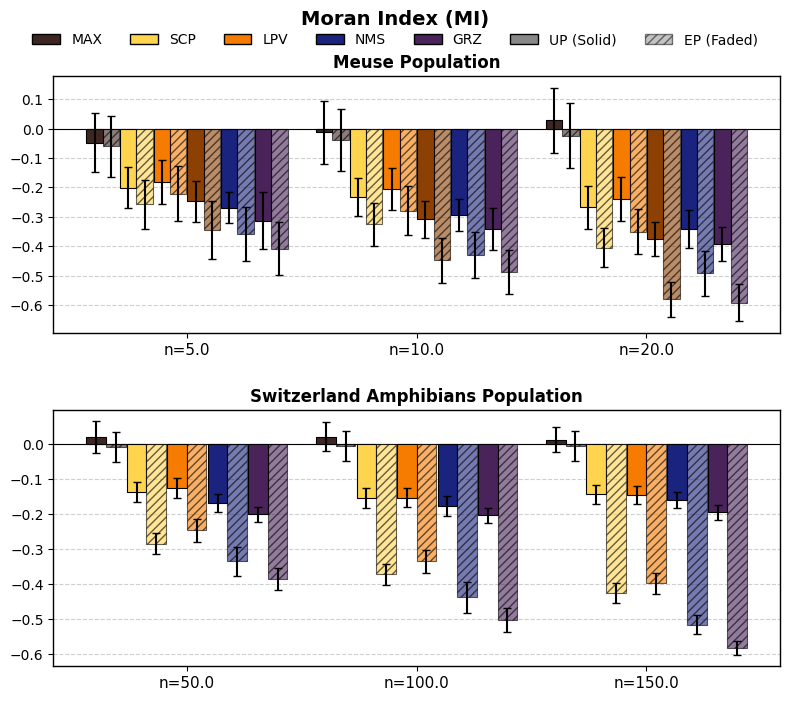

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_moran_meuse_swiss(save_plot=False):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 7), sharex=False)

    datasets = [
        ('meuse', 'Meuse Population'),
        ('swiss', 'Switzerland Amphibians Population')
    ]

    mean_col, std_col, metric_name = ('Mm', 'Ms', 'Moran (MI)')

    for ax, (dataset_name, title) in zip(axes, datasets):
        pop_data = master_summary[master_summary['Population'] == dataset_name]

        if pop_data.empty:
            ax.set_title(f"{title} (no data)")
            continue

        active_methods = [m for m in all_methods if m in pop_data['Method'].unique()]
        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))

        total_group_width = 0.88
        method_width = total_group_width / len(active_methods)
        bar_width = method_width * 0.485

        for i, method in enumerate(active_methods):
            m_data = pop_data[pop_data['Method'] == method]
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)

            offset = (i - len(active_methods)/2 + 0.5) * method_width

            # Unequal
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width,
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=0.8,
                   capsize=3, zorder=3)

            # Equal
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width,
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', linewidth=0.8,
                   hatch='////', alpha=0.6, capsize=3, zorder=3)

            ax.set_xticks(x_pos)
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)


        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axhline(0, color='black', linewidth=0.8)
        # ax.grid(False)
        ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.6)



        for spine in ax.spines.values():
            spine.set_linewidth(1.0)



    # Legend
    legend_elements = [mpatches.Patch(facecolor=color_dict[m], edgecolor='black', label=m)
                       for m in active_methods]
    legend_elements += [
        mpatches.Patch(facecolor='#888888', edgecolor='black', label='UP (Solid)'),
        mpatches.Patch(facecolor='#888888', edgecolor='black', hatch='////',
                       alpha=0.5, label='EP (Faded)')
    ]

    fig.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, 0.98), ncol=len(legend_elements),
               frameon=False, fontsize=10)

    fig.suptitle("Moran Index (MI)", fontsize=14, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, hspace=0.3)

    if save_plot:
        os.makedirs(SAVE_DIR, exist_ok=True)

        pdf_path = os.path.join(SAVE_DIR, "moran_meuse_swiss.pdf")
        png_path = os.path.join(SAVE_DIR, "moran_meuse_swiss.png")

        plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
        plt.savefig(png_path, dpi=300, bbox_inches='tight')

        print(f"✅ Saved: {pdf_path}")
        print(f"✅ Saved: {png_path}")

    plt.show()


# Run
plot_moran_meuse_swiss(save_plot=True)


## Store

In [54]:
raise SystemExit("Stopping Run All: Archived cells below.")

SystemExit: Stopping Run All: Archived cells below.

/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
color_dict = {
    'Maxe': '#FF0000',  # Pure Red
    'Scps': '#F6C667',  # Soft Amber
    'Lopi': '#73c6b6',  # Pastel Green
    'Wave': '#1a759f',  # Brighter Marine Blue
}
color_dict = {
    'Maxe': '#A93226',  # Muted Brick Red (Distinct & stands out)
    'Scps': '#85C1E9',  # Soft Cerulean Blue (Spreading method 1)
    'Lopi': '#2874A6',  # Deep Cobalt Blue (Spreading method 2)
    'Wave': '#154360',  # Midnight Navy (Spreading method 3)
}

color_dict = {
    'Maxe': '#D55E00',  # Vermillion / Deep Burnt Orange (Stands out immediately)
    'Scps': '#0072B2',  # Deep Ocean Blue (Spreading 1)
    'Lopi': '#009E73',  # Rich Bluish-Green / Emerald (Spreading 2)
    'Wave': '#CC79A7',  # Muted Magenta / Dusty Purple (Spreading 3)
}
color_dict = {
    'Maxe': '#595959',  # Classy Dark Gray (Clearly separates the non-spreading method)
    'Scps': '#F9E076',  # Warm Sun Yellow (Lightest)
    'Lopi': '#E5B235',  # Rich Gold (Medium)
    'Wave': '#C87A19',  # Deep Amber / Orange-Yellow (Darkest)
}
color_dict = {
    'Maxe': '#404040',  # Solid Charcoal Gray (The distinct baseline)
    'Scps': '#9ECAE1',  # Soft Light Blue (Light)
    'Lopi': '#4292C6',  # Medium Academic Blue (Medium)
    'Wave': '#08519C',  # Deep Navy Blue (Dark)
}
color_dict = {
    'Maxe': '#A6A6A6',  # Medium-Light Silver Gray (Much softer, clearly the neutral baseline)
    'Scps': '#FFD54F',  # Bright Sun Yellow (Lightest, but saturated enough to show up on white)
    'Lopi': '#F57C00',  # Vibrant Orange-Gold (A massive step darker than Scps)
    'Wave': '#8D4004',  # Deep Amber / Bronze (Very dark, ensuring it never blends with Lopi)
}
color_dict = {
    'Maxe': '#2C3E50',  # Deep Slate Blue (Striking contrast against the warm tones)
    'Scps': '#FFD54F',  # Bright Sun Yellow
    'Lopi': '#F57C00',  # Vibrant Orange-Gold
    'Wave': '#8D4004',  # Deep Amber / Bronze
}

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    # ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['rand', 'grid', 'clust']

all_methods = ['Maxe', 'Scps', 'Lopi', 'Wave']

color_dict = {
    'Maxe': '#FF0000',  # Pure Red
    'Scps': '#F6C667',  # Soft Amber
    'Lopi': '#73c6b6',  # Pastel Green
    'Wave': '#1a759f',  # Brighter Marine Blue
}

# Adjusted to standard academic page dimensions
fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(target_populations),
                         figsize=(7.5, 9.5), sharey='row')

fig.suptitle("The Three Simulated Populations",
             fontsize=14, fontweight='bold', y=0.98)

# Layout math for wider bars and NO gap between Equal/Unequal pairs
num_methods = len(all_methods)
total_cluster_width = 0.9  # Increased width of the entire cluster
method_width = total_cluster_width / num_methods
bar_width = method_width * 0.5  # Exactly half, so Equal/Unequal pairs touch perfectly

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):
        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]

        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))

        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]

            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)

            offset = (i - num_methods/2 + 0.5) * method_width

            # 1. Unequal (Plain Bar)
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width,
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black',
                   capsize=3,
                   error_kw={'elinewidth': 1, 'capthick': 0.5, 'ecolor': 'black'},
                   zorder=3)

            # 2. Equal (Hatched Bar)
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width,
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', hatch='////',
                   alpha=0.5,
                   capsize=3,
                   error_kw={'elinewidth': 1, 'capthick': 0.5, 'ecolor': 'gray'},
                   zorder=3)

        # --- Formatting ---
        if row_idx == 0: ax.set_title(pop.capitalize(), fontsize=11, fontweight='bold', pad=8)
        if col_idx == 0: ax.set_ylabel(metric_name, fontsize=10, fontweight='bold')

        ax.set_xticks(x_pos)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=9)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Build a smart custom legend
legend_elements = [mpatches.Patch(facecolor=color_dict[m], edgecolor='black', label=m) for m in all_methods]
legend_elements.append(mpatches.Patch(facecolor='white', edgecolor='white', label=' | '))
legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', label='Unequal (Solid)'))
legend_elements.append(mpatches.Patch(facecolor='#888888', edgecolor='black', hatch='////', alpha=0.5, label='Equal (Faded)'))

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=len(legend_elements), fontsize=9, frameon=False)

plt.tight_layout()

# Pulled the frames tightly together by minimizing wspace and hspace
plt.subplots_adjust(top=0.88, wspace=0.05, hspace=0.05)

# Save as a high-resolution PNG
save_path = "plot_synthetic_populations_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()

In [ ]:
color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo (From your "MAX")
    'Lopi': '#7FB685',  # Red (From your "WAV" / what was red in your legend)
    'Scps': '#F6C667',  # Pastel Green (From your "LP1")
    'Wave': '#FF0000',  # Soft Orange (From your "NMS")
}

color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}


color_dict = {
    'Maxe': '#8D6E63',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}
    # "Autumn & Earth": ['#FFCA28', '', '', '', '#1E88E5', '#D81B60'],#E65100

# color_dict = {
#     'Maxe': '#5C6B8C',  # Deeper Slate Blue
#     'Lopi': '#6EA174',  # Sage Green
#     'Scps': '#E5B25D',  # Warm Gold
#     'Wave': '#D93838',  # Brick Red
# }

# color_dict = {
#     'Maxe': '#8D6E63',  # Muted Cocoa
#     'Lopi': '#FBC02D',  # Golden Yellow
#     'Scps': '#E65100',  # Burnt Orange
#     'Wave': '#C62828',  # Deep Crimson
# }

# color_dict = {
#     'Maxe': '#424242',  # Dark Charcoal
#     'Lopi': '#9E9E9E',  # Neutral Grey
#     'Scps': '#E0E0E0',  # Light Silver
#     'Wave': '#E53935',  # Striking Red
# }






In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['rand', 'grid', 'clust']

all_methods = ['Maxe', 'Scps', 'Lopi', 'Wave']

color_dict = {
    'Maxe': '#73c6b6',  # Pastel Indigo/Teal
    'Lopi': '#004c6d',  # Deep Ocean Blue
    'Scps': '#F6C667',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}

fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(target_populations),
                         figsize=(14, 15), sharey='row')

fig.suptitle("The Three Simulated Populations",
             fontsize=16, fontweight='bold', y=0.98)

# Layout math: Every n has a cluster -> divided into Methods -> divided into 2 points (Unequal/Equal)
num_methods = len(all_methods)
total_cluster_width = 0.8
method_width = total_cluster_width / num_methods
bar_width = method_width * 0.45  # Keeps the spatial gap the same

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):
        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]

        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))

        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]

            # Align perfectly by index 'n'
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)

            # Shift the center for this specific method
            offset = (i - num_methods/2 + 0.5) * method_width

            # 1. Unequal (Solid Circle marker)
            yerr_un = un_data[std_col].values if std_col in un_data.columns else np.zeros(len(n_vals))
            ax.errorbar(x_pos + offset - bar_width/2, un_data[mean_col].values,
                        yerr=yerr_un, fmt='o', color=color_dict[method], ecolor=color_dict[method],
                        capsize=4, elinewidth=2.5, capthick=2.5, markersize=10, ls='none', zorder=3)

            # 2. Equal (Hollow Square marker)
            yerr_eq = eq_data[std_col].values if std_col in eq_data.columns else np.zeros(len(n_vals))
            ax.errorbar(x_pos + offset + bar_width/2, eq_data[mean_col].values,
                        yerr=yerr_eq, fmt='s', mfc='white', color=color_dict[method], ecolor=color_dict[method],
                        capsize=4, elinewidth=2.5, capthick=2.5, markersize=10, markeredgewidth=2.0, ls='none', zorder=3)
        # --- Formatting ---
        if row_idx == 0: ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)
        if col_idx == 0: ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')

        ax.set_xticks(x_pos)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)

        # Subtle gridlines to help read point values easily
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Build a smart custom legend for points instead of bars
legend_elements = [mlines.Line2D([], [], color=color_dict[m], marker='o', linestyle='None', markersize=8, label=m) for m in all_methods]
legend_elements.append(mlines.Line2D([], [], color='white', label=' | ')) # spacer
legend_elements.append(mlines.Line2D([], [], color='#555555', marker='o', linestyle='None', markersize=8, label='Unequal (Solid Circle)'))
legend_elements.append(mlines.Line2D([], [], color='#555555', marker='s', mfc='white', linestyle='None', markersize=8, label='Equal (Hollow Square)'))

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=len(legend_elements), fontsize=11, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.10, hspace=0.15)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. USER CONTROLS (Change these lists to reorder!)
# ==========================================

# 🔹 REARRANGE COLUMNS: Change the order of strings in this list to reorder your columns left-to-right
target_populations = ['meuse', 'rand', 'grid', 'clust']

# 🔹 REARRANGE ROWS: Change the order of these 4 lines to reorder your metrics top-to-bottom
target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Lm', 'Ls', 'Local Balance (L)')
]

# ==========================================
# 2. Data Preparation & Colors
# ==========================================

df_plot = master_summary[master_summary['Method'] != 'Rand'].copy()

# Ensure the populations actually exist in the data before plotting
pops = [p for p in target_populations if p in df_plot['Population'].unique()]

# Define Method Ordering
all_methods = df_plot['Method'].unique().tolist()
if 'Maxe' in all_methods:
    all_methods.remove('Maxe')
    methods_order = ['Maxe'] + sorted(all_methods)
else:
    methods_order = sorted(all_methods)


# ==========================================
# 3. Plotting Engine
# ==========================================

fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(pops), figsize=(12, 10), sharey='row')

# Add the main overarching title
fig.suptitle("Comparison of Sampling Designs under Unequal Inclusion Probabilities",
             fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]

        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))
        width = 0.8 / len(methods_order)

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n')
            method_data = method_data.reindex(n_vals)

            means = method_data[mean_col].values
            stds = method_data[std_col].values

            offset = (i - len(methods_order)/2 + 0.5) * width

            ax.bar(x + offset, means, width, yerr=stds,
                   label=method if (row_idx == 0 and col_idx == 0) else "",
                   color=color_dict.get(method, '#888888'),
                   capsize=3, edgecolor='black', linewidth=1.0,
                   error_kw={'elinewidth': 1.0, 'capthick': 1.0}, zorder=3)

        # --- Formatting for the "Plain Sheet" Look ---
        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)

        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')

        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)

        # 1. Turn off all inner grid lines
        ax.grid(False)

        # 2. Force the standard box border around the plot to stay visible
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Add the master legend
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order),
           fontsize=12, frameon=False)

plt.tight_layout()
# Adjust top spacing to make room for both the suptitle and the legend
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Point & Error Visualization", fontsize=16, fontweight='bold', y=0.98)

markers = ['o', 's', '^', 'D', 'P', '*', 'X']  # One per method

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.errorbar(x, means, yerr=stds, fmt=markers[i % len(markers)],
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=7, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

In [ ]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Trends Across Sample Sizes", fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.plot(n_vals, means, marker='o', color=color_dict.get(method, '#888888'),
                    label=method if (row_idx == 0 and col_idx == 0) else "", zorder=3)
            ax.fill_between(n_vals, means - stds, means + stds, color=color_dict.get(method, '#888888'), alpha=0.2)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(n_vals)
        ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11 if row_idx == len(target_metrics) - 1 else 0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

In [ ]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Stripplot Overview", fontsize=16, fontweight='bold', y=0.98)

jitter_strength = 0.1

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_base = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(x_base))
            ax.errorbar(x_base + jitter, means, yerr=stds, fmt='o',
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=6, alpha=0.8, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x_base)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

### New plots

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- CELL 1: Read the Data ---

# Define the folder paths
folder_unequal = 'unequal_M=5000'  # You mentioned unequal_N=500 in the prompt
folder_equal = 'equal_M=5000'

def load_population_data(folder_path, prob_type):
    """
    Template function to read results from a folder.
    Adapt this based on how your files are structured (e.g., CSVs).
    """
    df_list = []
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'): # Assuming your results are in CSV files
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['Probability'] = prob_type

                # Tag the population type based on the filename
                for pop in ['rand', 'clust', 'grid', 'meuse']:
                    if pop in file.lower():
                        df['Population'] = pop

                df_list.append(df)
        if df_list:
            return pd.concat(df_list, ignore_index=True)

    print(f"Warning: Folder '{folder_path}' not found or empty.")
    return pd.DataFrame()

# Load and combine datasets
df_unequal = load_population_data(folder_unequal, 'Unequal')
df_equal = load_population_data(folder_equal, 'Equal')

if not df_unequal.empty and not df_equal.empty:
    df_all = pd.concat([df_unequal, df_equal], ignore_index=True)
    print("Data successfully loaded!")
else:
    print("Please make sure your data folders exist and contain the files.")

# NOTE: In the plots below, dummy data is generated to show you the exact layout.
# You will replace the dummy data variables with actual filtering from `df_all`.